**Cell 0: The Ultimate Seed Lock**

lock and the os environment variable that Python sometimes needs to freeze hash randomization

In [1]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 1.5 MB/s  0:00:06a 0:00:010:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]━━━━ 1/2 [plotly]


In [1]:
import os
import random
import numpy as np
import torch

In [2]:
def seed_everything(seed_value=42):
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)

    # Lock PyTorch
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(42)
print("Randomness Locked. Results will be 100% reproducible.")

Randomness Locked. Results will be 100% reproducible.


**Cell 1: The Tool Cart (Installs & Imports)**

Ensuring Colab has the Hugging Face datasets and transformers libraries to grab the DistilBERT tokenizer and the clean IMDb data.

In [3]:
# CELL 1:
!pip install datasets transformers -q

# The OpenMP Quarantine: Must happen BEFORE PyTorch is imported!
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from datasets import load_dataset
from transformers import DistilBertTokenizer

import numpy as np
import time

print("Environment Ready. PyTorch imported successfully.")

Environment Ready. PyTorch imported successfully.


**Loading Tokenizer**

In [4]:
print("1. Loading DistilBERT Tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
vocab_size = tokenizer.vocab_size
max_length = 200

print(f"Verified Tokenizer Vocab Size: {vocab_size}")

1. Loading DistilBERT Tokenizer...


Verified Tokenizer Vocab Size: 30522


**Cell 2: The Intake Manifold (Data Pipeline)**

Bypassed the old Keras integer loader and use the official Hugging Face DistilBERT tokenizer. We will take a subset of the IMDb dataset (2,000 train / 500 test) just for today's rapid prototyping

**Cell 2.1: Download & Tokenize**

This cell downloads Little Yelp and applies the tokenizer

In [5]:
print("1. Loading Local 3.6M Imbalanced CSV...")

# Load the local CSV file (Hugging Face automatically puts it all in a 'train' split)
full_dataset = load_dataset("csv", data_files="yelp_3_6M_imbalanced.csv", split="train")

print("Splitting into 90% Training and 10% Testing...")
# We must manually split it. 10% of 3.6M is 360,000 testing samples (which is massive and perfect)
dataset = full_dataset.train_test_split(test_size=0.1, seed=42)

# Now your old variables will work perfectly!
train_data = dataset['train']
test_data = dataset['test']

print(f"Loaded {len(train_data):,} training samples and {len(test_data):,} testing samples.")

print("\n2. Tokenizing and Padding Data using .map()...")
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=max_length
    )

# Add num_proc=14 to perfectly balance CPU speed and RAM safety
tokenized_train = train_data.map(tokenize_function, batched=True, num_proc=14)
tokenized_test = test_data.map(tokenize_function, batched=True, num_proc=14)
print("Tokenization Complete!")

1. Loading Local 3.6M Imbalanced CSV...


Generating train split: 0 examples [00:00, ? examples/s]

Splitting into 90% Training and 10% Testing...
Loaded 3,240,000 training samples and 360,000 testing samples.

2. Tokenizing and Padding Data using .map()...


Map (num_proc=14):   0%|          | 0/3240000 [00:00<?, ? examples/s]

Map (num_proc=14):   0%|          | 0/360000 [00:00<?, ? examples/s]

Tokenization Complete!


**2.2 Tensor Extraction & Dataset Diagnostic**

This cell extracts the raw numbers into PyTorch format and immediately runs your new Class Balance check so you know exactly what kind of data the model is about to see.

In [6]:
print("3. Extracting PyTorch Tensors...")

# Convert directly to PyTorch Tensors
X_train = torch.tensor(tokenized_train['input_ids'], dtype=torch.long)
y_train = torch.tensor(tokenized_train['label'], dtype=torch.float32)

X_test = torch.tensor(tokenized_test['input_ids'], dtype=torch.long)
y_test = torch.tensor(tokenized_test['label'], dtype=torch.float32)

print("\n============== DATASET BALANCE DIAGNOSTIC ==============")
# Calculate pure counts for Training Set
train_pos = sum(1 for label in y_train if label == 1)
train_neg = sum(1 for label in y_train if label == 0)
train_total = len(y_train)

# Calculate pure counts for Testing Set
test_pos = sum(1 for label in y_test if label == 1)
test_neg = sum(1 for label in y_test if label == 0)
test_total = len(y_test)

# Print with exact numbers and percentages
print(f"Training Set ({train_total:,} total):")
print(f"  ➔ Positive: {train_pos:,} ({(train_pos/train_total)*100:.1f}%)")
print(f"  ➔ Negative: {train_neg:,} ({(train_neg/train_total)*100:.1f}%)\n")

print(f"Testing Set ({test_total:,} total):")
print(f"  ➔ Positive: {test_pos:,} ({(test_pos/test_total)*100:.1f}%)")
print(f"  ➔ Negative: {test_neg:,} ({(test_neg/test_total)*100:.1f}%)")
print("========================================================\n")

3. Extracting PyTorch Tensors...

============== DATASET BALANCE DIAGNOSTIC ==============
Training Set (3,240,000 total):
  ➔ Positive: 2,267,878 (70.0%)
  ➔ Negative: 972,122 (30.0%)

Testing Set (360,000 total):
  ➔ Positive: 252,122 (70.0%)
  ➔ Negative: 107,878 (30.0%)



**2.3 DataLoader Construction**

Now that you've verified the balance, this final cell packages the tensors into the engines that will feed the A2000 GPU.

In [8]:
print("4. Building DataLoaders for GPU...")

BATCH_SIZE = 256 

# Wrap Tensors into PyTorch Datasets
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# Build the DataLoaders (The data engines)
# pin_memory=True is a massive GPU speed hack for PyTorch
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f"Data Pipeline Built Successfully!")
print(f"Train batches: {len(train_loader):,} | Test batches: {len(test_loader):,}")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")

4. Building DataLoaders for GPU...
Data Pipeline Built Successfully!
Train batches: 12,657 | Test batches: 1,407
X_train shape: torch.Size([3240000, 200]) | y_train shape: torch.Size([3240000])


**Cell 3: CURA - the engine**

In [9]:
# CELL 3: CURA ARCHITECTURE
class CURA_Engine(nn.Module):
    def __init__(self, vocab_size=30522, embed_dim=128, hidden_dim=22):
        super().__init__()
        # The exact same embedding shape as the CNN
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # 1- Gate circuit
        self.gate_fc = nn.Linear(embed_dim, hidden_dim)
        # 2- Residual path
        self.residual_fc = nn.Linear(embed_dim, hidden_dim)
        # 3- Nonlinear amplifier
        self.relu_linear = nn.Linear(hidden_dim, hidden_dim)
        # 4- CNN filter (1-channel bandpass)
        self.conv = nn.Conv1d(in_channels=1, out_channels=1, kernel_size=3, padding=1)
        # 5- Output buffer (Binary classification = 1 output neuron)
        self.output = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # Read the text and pool it into a single dense vector
        x = self.embedding(x)
        x = torch.max(x, dim=1)[0] # Global Max Pooling

        # Gating & Residual
        gate = torch.sigmoid(self.gate_fc(x))
        residual = self.residual_fc(x)
        x = gate * residual + residual

        # Amplifier
        x = F.relu(self.relu_linear(x))

        # CNN filter (Requires 3D tensor manipulation for PyTorch)
        x_cnn = self.conv(x.unsqueeze(1)).squeeze(1)

        # Output buffer
        out = self.output(x_cnn)
        return torch.sigmoid(out).squeeze()

# THE FIX: Force random reset immediately before building the engine
seed_everything(42)
# Instantiate the engine
cura_model = CURA_Engine(vocab_size=vocab_size)
# Calculate the total parameters (including the massive DistilBERT dictionary)
cura_total_params = sum(p.numel() for p in cura_model.parameters() if p.requires_grad)

# Calculate ONLY the core engine parameters (excluding the embedding layer)
cura_core_params = sum(p.numel() for name, p in cura_model.named_parameters() 
                       if 'embedding' not in name and p.requires_grad)

print(f"CURA Total Parameters: {cura_total_params:,}")
print(f"CURA Core Parameters (Thinking Brain Only): {cura_core_params:,}")
print("CURA Engine successfully mounted.")

CURA Total Parameters: 3,913,025
CURA Core Parameters (Thinking Brain Only): 6,209
CURA Engine successfully mounted.


**Cell 4: The Heavy 1D-CNN Engine**

64 channels instead of 8, and 128 dense neurons

In [10]:
import torch
import torch.nn as nn

class NLP_1DCNN_Unfair(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, seq_len=200):
        super(NLP_1DCNN_Unfair, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        
        # The SOTA Tabular Hyperparameters (Massive)
        self.conv1 = nn.Conv1d(in_channels=embed_dim, out_channels=64, kernel_size=3, stride=1)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        
        # Math: Seq=200 -> Conv=198 -> MaxPool=99. 99 * 64 channels = 6336 flat features
        self.fc1 = nn.Linear(6336, 128)  
        self.fc2 = nn.Linear(128, 1)     
        
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        x = x.transpose(1, 2)
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc2(x))
        return x

print("1D-CNN mounted suucessfully")
# --- MODEL DIAGNOSTICS (Paste at the bottom of Engine Cell) ---

def print_model_compactness(model, model_name="Model"):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Automatically find the embedding layer size if it exists
    emb_params = 0
    if hasattr(model, 'embedding'):
        emb_params = sum(p.numel() for p in model.embedding.parameters())
    
    core_params = total_params - emb_params

    print(f"\n--- {model_name} COMPACTNESS METRICS ---")
    print(f"Total Parameters:      {total_params:,}")
    print(f"Trainable Parameters:  {trainable_params:,}")
    print(f"Embedding Layer Size:  {emb_params:,}")
    print(f"Core Engine Size:      {core_params:,}")
    print("---------------------------------------")

# (Optional) If you want the Engine cell to prove its size the second you run it:
# You can uncomment these two lines, assuming your tokenizer is already loaded from Cell 1!
test_cnn = NLP_1DCNN_Unfair(vocab_size=len(tokenizer.get_vocab()))
print_model_compactness(test_cnn, "1D-CNN (UnFair , heavy)")

1D-CNN mounted suucessfully

--- 1D-CNN (UnFair , heavy) COMPACTNESS METRICS ---
Total Parameters:      4,742,721
Trainable Parameters:  4,742,721
Embedding Layer Size:  3,906,816
Core Engine Size:      835,905
---------------------------------------


**1D-CNN Training**


In [11]:
print("\n==============HEAVY TRAINING 1D-CNN ==============")

# Initialize the Fair version for Phase 1 
# (Swap to NLP_1DCNN_Unfair later for Phase 2)
cnn_model = NLP_1DCNN_Unfair(vocab_size=len(tokenizer.get_vocab()))
# 2. Print the compactness (Calling the function from the Engine cell)
print_model_compactness(cnn_model, "1D-CNN (Phase 1 Baseline)")

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model.to(device)
cnn_model.train()

epochs = 3

print(f"Starting 1D-CNN Endurance Run on {device}...")
cnn_master_start = time.time()

cnn_train_losses = []

for epoch in range(epochs):
    epoch_start = time.time()
    running_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        # Move to GPU and fix label shape
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device).view(-1, 1)
        
        optimizer.zero_grad()
        outputs = cnn_model(batch_X)
        
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    # --- END OF EPOCH BOUNDARY ---
    epoch_loss = running_loss / len(train_loader)
    cnn_train_losses.append(epoch_loss)
    
    epoch_time = time.time() - epoch_start
    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss:.4f} | Time: {epoch_time:.2f}s")

cnn_total_time = time.time() - cnn_master_start
print(f"✅ CNN Training Complete! Total Time: {cnn_total_time:.2f}s")


==============HEAVY TRAINING 1D-CNN ==============

--- 1D-CNN (Phase 1 Baseline) COMPACTNESS METRICS ---
Total Parameters:      4,742,721
Trainable Parameters:  4,742,721
Embedding Layer Size:  3,906,816
Core Engine Size:      835,905
---------------------------------------
Starting 1D-CNN Endurance Run on cuda...
Epoch [1/3] | Loss: 0.1266 | Time: 120.34s
Epoch [2/3] | Loss: 0.0874 | Time: 119.66s
Epoch [3/3] | Loss: 0.0765 | Time: 119.50s
✅ CNN Training Complete! Total Time: 359.49s


**CURA Training**

This is exact 16-line standalone CURA code, but wrapped inside a complete module that includes the Embedding layer and a Global Max Pooling step so it can read the 200-word sequences from DistilBERT.

In [12]:
print("\n============== TRAINING CURA ==============")

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(cura_model.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch is using: {device}")
cura_model.to(device)
cura_model.train()
epochs = 3

print("Starting CURA Endurance Run...")
cura_master_start = time.time()

cura_train_losses = []

for epoch in range(epochs):
    epoch_start = time.time()
    running_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
        optimizer.zero_grad()
        predictions = cura_model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
    # --- END OF EPOCH BOUNDARY ---
    epoch_loss = running_loss / len(train_loader)    
    cura_train_losses.append(epoch_loss)  
    
    epoch_time = time.time() - epoch_start
    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss:.4f} | Time: {epoch_time:.2f}s")
    
cura_master_end = time.time() - cura_master_start
print(f"==================================================")
print(f"✅ CURA TOTAL TRAINING TIME: {cura_master_end:.2f}s")
print(f"==================================================")
print("\nEngines tuned and ready")


============== TRAINING CURA ==============
PyTorch is using: cuda
Starting CURA Endurance Run...
Epoch [1/3] | Loss: 0.1652 | Time: 73.90s
Epoch [2/3] | Loss: 0.1248 | Time: 74.34s
Epoch [3/3] | Loss: 0.1180 | Time: 74.22s
✅ CURA TOTAL TRAINING TIME: 222.46s

Engines tuned and ready


**The Model Saving Cell**


In [13]:
import torch
import os

print("============== SAVING TRAINED ENGINES ==============")

# Define the relative path (up one folder, then into Trained_weights)
weights_dir = "../Trained_weights/Heavy_weight/"

# SAFETY LOCK: Create the folder automatically if it doesn't exist
os.makedirs(weights_dir, exist_ok=True)

print(f"Target directory established: {weights_dir}/")

# Save CURA Weights
cura_save_path = os.path.join(weights_dir, "CURA_RAW_Yelp_Weights.pth")
torch.save(cura_model.state_dict(), cura_save_path)
print(f"✅ CURA successfully saved: {cura_save_path}")

# Save 1D-CNN Weights
cnn_save_path = os.path.join(weights_dir, "1D_CNN_RAW_Yelp_Weights.pth")
torch.save(cnn_model.state_dict(), cnn_save_path)
print(f"✅ Heavy_1D-CNN successfully saved: {cnn_save_path}")
print("====================================================")

============== SAVING TRAINED ENGINES ==============
Target directory established: ../Trained_weights/Heavy_weight//
✅ CURA successfully saved: ../Trained_weights/Heavy_weight/CURA_RAW_Yelp_Weights.pth
✅ Heavy_1D-CNN successfully saved: ../Trained_weights/Heavy_weight/1D_CNN_RAW_Yelp_Weights.pth


**Inference Speed & Model Compactness**


In [14]:
import time
import torch
import numpy as np

print("============== EDGE COMPUTING METRICS ==============")

# 1. Model Compactness
print_model_compactness(cura_model, "CURA")
print_model_compactness(cnn_model, "1D-CNN")

# 2. Computational Efficiency (Inference Speed)
print("\nRunning Inference Speed Test on GPU...")
cura_model.eval()
cnn_model.eval()

y_true_all = []
cura_probs_all = []
cnn_probs_all = []

# Time CURA Inference
# torch.cuda.synchronize() ensures the GPU finishes math before stopping the clock
if torch.cuda.is_available(): torch.cuda.synchronize()
cura_start = time.time()
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        probs = cura_model(batch_X)
        cura_probs_all.extend(probs.cpu().numpy())
        y_true_all.extend(batch_y.numpy())
if torch.cuda.is_available(): torch.cuda.synchronize()
cura_infer_time = time.time() - cura_start

# Time CNN Inference
if torch.cuda.is_available(): torch.cuda.synchronize()
cnn_start = time.time()
with torch.no_grad():
    for batch_X, _ in test_loader:
        batch_X = batch_X.to(device)
        probs = cnn_model(batch_X)
        cnn_probs_all.extend(probs.cpu().numpy())
if torch.cuda.is_available(): torch.cuda.synchronize()
cnn_infer_time = time.time() - cnn_start

# Flatten lists into clean arrays for Scikit-Learn
y_true_all = np.array(y_true_all).flatten()
cura_probs_all = np.array(cura_probs_all).flatten()
cnn_probs_all = np.array(cnn_probs_all).flatten()

print(f"CURA Total Inference Time:   {cura_infer_time:.4f} seconds")
print(f"1D-CNN Total Inference Time: {cnn_infer_time:.4f} seconds")
print(f"Speedup Multiplier:          {cnn_infer_time / cura_infer_time:.2f}x faster")
print("====================================================")

============== EDGE COMPUTING METRICS ==============

--- CURA COMPACTNESS METRICS ---
Total Parameters:      3,913,025
Trainable Parameters:  3,913,025
Embedding Layer Size:  3,906,816
Core Engine Size:      6,209
---------------------------------------

--- 1D-CNN COMPACTNESS METRICS ---
Total Parameters:      4,742,721
Trainable Parameters:  4,742,721
Embedding Layer Size:  3,906,816
Core Engine Size:      835,905
---------------------------------------

Running Inference Speed Test on GPU...
CURA Total Inference Time:   3.8363 seconds
1D-CNN Total Inference Time: 5.5889 seconds
Speedup Multiplier:          1.46x faster


**Classification Report**


In [15]:
from sklearn.metrics import classification_report

print("============== PREDICTIVE PERFORMANCE ==============")

# Convert raw probabilities to 0 or 1 using the 0.5 threshold
cura_preds = (cura_probs_all >= 0.5).astype(int)
cnn_preds = (cnn_probs_all >= 0.5).astype(int)

print("\n[CURA Classification Report]")
print(classification_report(y_true_all, cura_preds, target_names=["Negative", "Positive"], digits=4))

print("\n[1D-CNN Classification Report]")
print(classification_report(y_true_all, cnn_preds, target_names=["Negative", "Positive"], digits=4))

============== PREDICTIVE PERFORMANCE ==============

[CURA Classification Report]
              precision    recall  f1-score   support

    Negative     0.9060    0.9396    0.9225    107878
    Positive     0.9738    0.9583    0.9659    252122

    accuracy                         0.9527    360000
   macro avg     0.9399    0.9489    0.9442    360000
weighted avg     0.9534    0.9527    0.9529    360000


[1D-CNN Classification Report]
              precision    recall  f1-score   support

    Negative     0.9505    0.9550    0.9527    107878
    Positive     0.9807    0.9787    0.9797    252122

    accuracy                         0.9716    360000
   macro avg     0.9656    0.9669    0.9662    360000
weighted avg     0.9717    0.9716    0.9716    360000



**The Loss Curves**


In [16]:
import plotly.graph_objects as go

print("Rendering Loss Curves via Plotly...")

epochs_range = list(range(1, len(cura_train_losses) + 1))

fig = go.Figure()

# Add CURA Line
fig.add_trace(go.Scatter(x=epochs_range, y=cura_train_losses, 
                         mode='lines+markers', name='CURA Training Loss',
                         line=dict(color='blue', width=3), marker=dict(size=10)))

# Add CNN Line
fig.add_trace(go.Scatter(x=epochs_range, y=cnn_train_losses, 
                         mode='lines+markers', name='1D-CNN Training Loss',
                         line=dict(color='red', width=3), marker=dict(symbol='x', size=10)))

fig.update_layout(title='Training Stability: CURA vs 1D-CNN',
                  xaxis_title='Epochs',
                  yaxis_title='Binary Cross-Entropy Loss',
                  template='plotly_white',
                  hovermode='x unified')
#
results_dir = "../Results/Heavy_weight/RAW_Yelp"
os.makedirs(results_dir, exist_ok=True)

fig.write_html(f"{results_dir}/1_Loss_Curves.html")
print(f"✅ Graph saved to {results_dir}/1_Loss_Curves.html")

Rendering Loss Curves via Plotly...
✅ Graph saved to ../Results/Heavy_weight/RAW_Yelp/1_Loss_Curves.html


**Side-by-Side Confusion Matrices**


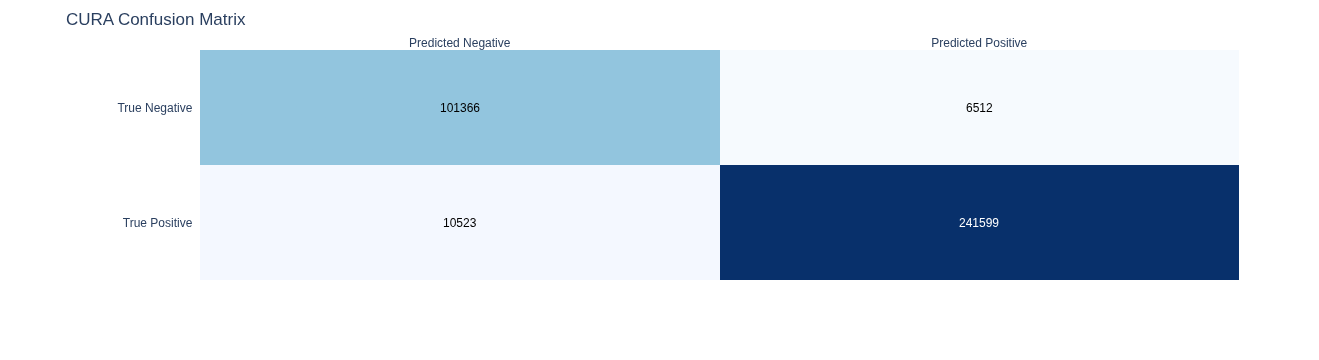

✅ Matrices saved to ../Results/Heavy_weight/RAW_Yelp/


In [17]:
import plotly.figure_factory as ff
from sklearn.metrics import confusion_matrix
import numpy as np

# Calculate matrices
cm_cura = confusion_matrix(y_true_all, cura_preds)
cm_cnn = confusion_matrix(y_true_all, cnn_preds)

x_labels = ['Predicted Negative', 'Predicted Positive']
y_labels = ['True Negative', 'True Positive']

# CURA Heatmap
fig_cura = ff.create_annotated_heatmap(z=cm_cura[::-1], x=x_labels, y=y_labels[::-1], colorscale='Blues')
fig_cura.update_layout(title_text='CURA Confusion Matrix', margin=dict(t=50, l=200))
fig_cura.show()

# CNN Heatmap
fig_cnn = ff.create_annotated_heatmap(z=cm_cnn[::-1], x=x_labels, y=y_labels[::-1], colorscale='Reds')
fig_cnn.update_layout(title_text='1D-CNN Confusion Matrix', margin=dict(t=50, l=200))


results_dir = "../Results/Heavy_weight/RAW_Yelp"
os.makedirs(results_dir, exist_ok=True)

fig_cura.write_html(f"{results_dir}/2_CURA_Confusion_Matrix.html")
fig_cnn.write_html(f"{results_dir}/3_CNN_Confusion_Matrix.html")
print(f"✅ Matrices saved to {results_dir}/")

**The "Racing Graph" (ROC Curve)**


In [18]:
from sklearn.metrics import roc_curve, auc

fpr_cura, tpr_cura, _ = roc_curve(y_true_all, cura_probs_all)
roc_auc_cura = auc(fpr_cura, tpr_cura)

fpr_cnn, tpr_cnn, _ = roc_curve(y_true_all, cnn_probs_all)
roc_auc_cnn = auc(fpr_cnn, tpr_cnn)

fig = go.Figure()

fig.add_trace(go.Scatter(x=fpr_cura, y=tpr_cura, mode='lines', 
                         name=f'CURA (AUC = {roc_auc_cura:.4f})', line=dict(color='blue', width=3)))

fig.add_trace(go.Scatter(x=fpr_cnn, y=tpr_cnn, mode='lines', 
                         name=f'1D-CNN (AUC = {roc_auc_cnn:.4f})', line=dict(color='red', width=3)))

# 50/50 Guessing Line
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', 
                         name='Random Guess', line=dict(color='gray', width=2, dash='dash')))

fig.update_layout(title='Receiver Operating Characteristic (ROC) Curve',
                  xaxis_title='False Positive Rate',
                  yaxis_title='True Positive Rate',
                  template='plotly_white',
                  width=800, height=600)


results_dir = "../Results/Heavy_weight/RAW_Yelp"
os.makedirs(results_dir, exist_ok=True)

fig.write_html(f"{results_dir}/4_ROC_Curve.html")
print(f"✅ ROC Curve saved to {results_dir}/4_ROC_Curve.html")

✅ ROC Curve saved to ../Results/Heavy_weight/RAW_Yelp/4_ROC_Curve.html


**The Pareto Frontier (Trade-Off Scatter Plot)**


In [19]:
from sklearn.metrics import f1_score

print("============== THE PARETO FRONTIER ==============")

cura_f1 = f1_score(y_true_all, cura_preds, average='macro')
cnn_f1 = f1_score(y_true_all, cnn_preds, average='macro')

fig = go.Figure()

# Add Models as giant dots
fig.add_trace(go.Scatter(
    x=[cura_infer_time, cnn_infer_time], 
    y=[cura_f1, cnn_f1],
    mode='lines+markers+text',
    line=dict(color='gray', width=2, dash='dash'),
    marker=dict(size=25, color=['blue', 'red'], line=dict(width=2, color='black')),
    text=[f"CURA<br>Time: {cura_infer_time:.4f}s<br>F1: {cura_f1:.4f}", 
          f"1D-CNN<br>Time: {cnn_infer_time:.4f}s<br>F1: {cnn_f1:.4f}"],
    textposition=["top center", "top center"],
    textfont=dict(size=14, color="black"),
    name='Pareto Frontier'
))

fig.update_layout(
    title='The Pareto Frontier: Hardware Cost vs. Predictive Power',
    xaxis_title='Total Inference Time (Seconds) ➔ [Lower / Further Left is Better]',
    yaxis_title='Macro F1-Score ➔ [Higher / Further Up is Better]',
    template='plotly_white',
    showlegend=False,
    width=900, height=600
)

# Give the graph dynamic breathing room
fig.update_xaxes(range=[0, max(cura_infer_time, cnn_infer_time) * 1.5])
fig.update_yaxes(range=[min(cura_f1, cnn_f1) - 0.05, max(cura_f1, cnn_f1) + 0.05])


results_dir = "../Results/Heavy_weight/RAW_Yelp"
os.makedirs(results_dir, exist_ok=True)

fig.write_html(f"{results_dir}/5_Pareto_Frontier.html")
print(f"✅ Pareto Frontier saved to {results_dir}/5_Pareto_Frontier.html")

============== THE PARETO FRONTIER ==============
✅ Pareto Frontier saved to ../Results/Heavy_weight/RAW_Yelp/5_Pareto_Frontier.html


##### 